# Endpoints
status_url = https://<framework-domain>/sunrise6g/experiment/status
data_url   = https://<framework-domain>/sunrise6g/experiment/data

# Status payload

{
  "exp_id": "6de48d00-5dfc-43c8-ba7d-23c32927a640",
  "status": "RUNNING"
}

### Allowed status values

According to your OpenAPI spec, the valid values are:

- PENDING
- RUNNING
- COMPLETED
- FAILED
- CANCELED




# Data payload

```
{
  "experiment": {
    "exp_id": "6de48d00-5dfc-43c8-ba7d-23c32927a640",
    "source": "ISI-UC1-Testbed"
  },
  "data": [
    {
      "timestamp": "2026-04-08T10:30:00Z",
      "moids": [
        {
          "name": "cell_id",
          "value": "123"
        }
      ],
      "kpis": [
        {
          "name": "throughput",
          "value": "98.5",
          "unit": "Mbps"
        },
        {
          "name": "latency",
          "value": "12.3",
          "unit": "ms"
        }
      ]
    }
  ]
}
```

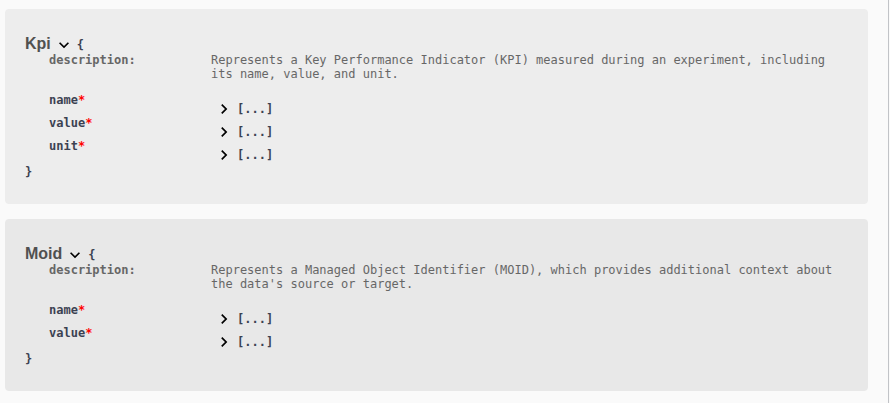

### Reusable Code

In [ ]:
import requests
from datetime import datetime, timezone


def send_experiment_status(status_url: str, exp_id: str, status: str) -> None:
    """
    Send experiment status to the Adaptation Framework.

    Valid statuses:
      - PENDING
      - RUNNING
      - COMPLETED
      - FAILED
      - CANCELED
    """
    payload = {
        "exp_id": exp_id,
        "status": status
    }

    response = requests.post(status_url, json=payload, timeout=5)
    response.raise_for_status()


def send_experiment_data(
    data_url: str,
    exp_id: str,
    source: str,
    kpis: list[dict],
    moids: list[dict] | None = None
) -> None:
    """
    Send experiment KPI/data to the Adaptation Framework.

    Example kpis:
    [
        {"name": "throughput", "value": "95.2", "unit": "Mbps"},
        {"name": "latency", "value": "10.1", "unit": "ms"}
    ]

    Example moids:
    [
        {"name": "cell_id", "value": "123"}
    ]
    """
    payload = {
        "experiment": {
            "exp_id": exp_id,
            "source": source
        },
        "data": [
            {
                "timestamp": datetime.now(timezone.utc).isoformat(),
                "moids": moids or [],
                "kpis": kpis
            }
        ]
    }

    response = requests.post(data_url, json=payload, timeout=5)
    response.raise_for_status()

# Example when experiment start:

send_experiment_status(status_url, exp_id, "PENDING")


# Example While experiment is running

```
send_experiment_status(status_url, exp_id, "RUNNING")

send_experiment_data(
    data_url=data_url,
    exp_id=exp_id,
    source="ISI-UC1-Testbed",
    kpis=[
        {"name": "dummy_kpi", "value": "87.4", "unit": "%"}
    ]
)
```